<a href="https://colab.research.google.com/github/jelissad-29/2067-html-css-desarrollo-estructura-archivos/blob/main/Telecom_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

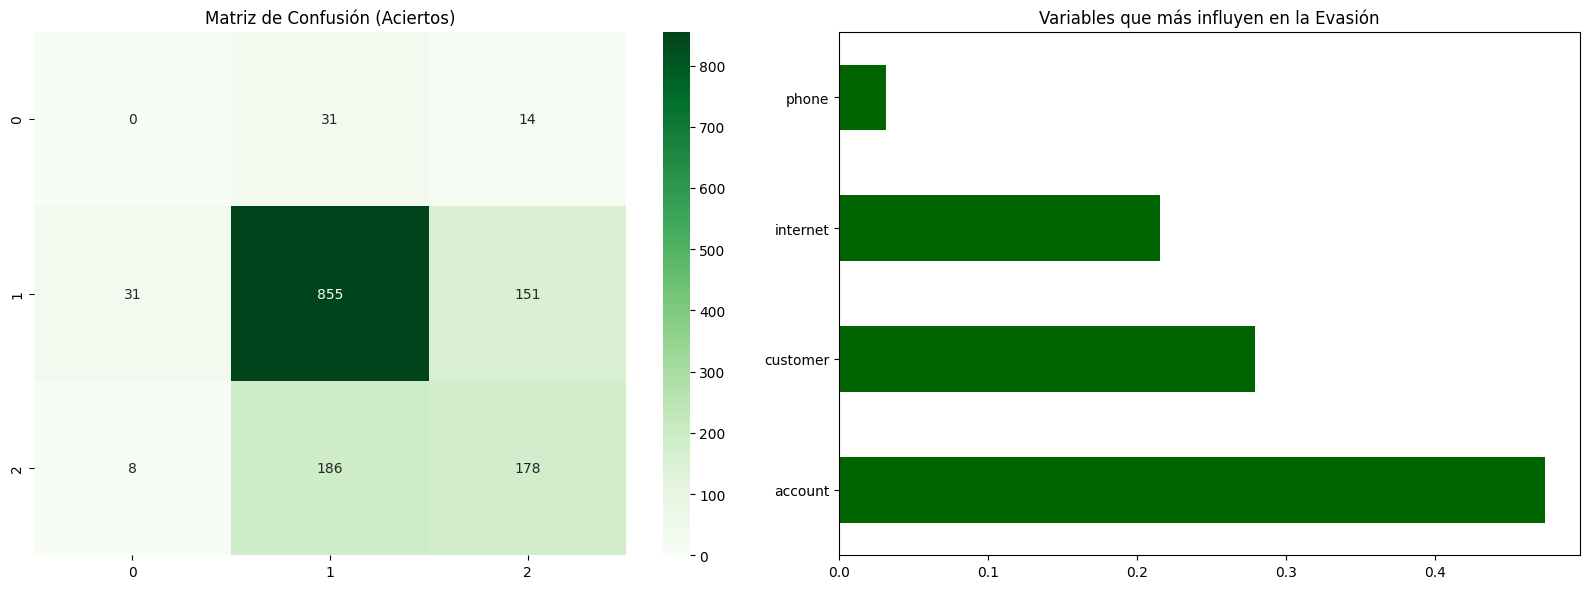

✅ ¡SISTEMA COMPLETADO! Ya puedes subirlo a GitHub.


In [8]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. CARGA DIRECTA
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
df = pd.DataFrame(requests.get(url).json())

# 2. BUSCADOR DINÁMICO DE COLUMNAS (Para evitar el KeyError)
# Buscamos la columna de Cargos Totales y Evasión sin importar el nombre
col_total = next((c for c in df.columns if 'Total' in c or 'Gasto' in c), None)
col_evasion = next((c for c in df.columns if 'Churn' in c or 'Evas' in c), None)

if col_total:
    df[col_total] = pd.to_numeric(df[col_total], errors='coerce').fillna(0)
    df.rename(columns={col_total: 'Cargos_Totales'}, inplace=True)

if col_evasion:
    df.rename(columns={col_evasion: 'Evasion'}, inplace=True)

# 3. LIMPIEZA AUTOMÁTICA DE TEXTO A NÚMEROS
df_ml = df.drop(columns=[c for c in df.columns if 'ID' in c], errors='ignore').copy()
le = LabelEncoder()
for col in df_ml.columns:
    if df_ml[col].dtype == 'object':
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# 4. ENTRENAMIENTO DEL MODELO
X = df_ml.drop('Evasion', axis=1, errors='ignore')
y = df_ml['Evasion'] if 'Evasion' in df_ml.columns else df_ml.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 5. GRÁFICOS FINALES
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(confusion_matrix(y_test, modelo.predict(X_test)), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Matriz de Confusión (Aciertos)')

importancias = pd.Series(modelo.feature_importances_, index=X.columns)
importancias.nlargest(10).plot(kind='barh', color='darkgreen', ax=ax[1])
ax[1].set_title('Variables que más influyen en la Evasión')

plt.tight_layout()
plt.show()

print("✅ ¡SISTEMA COMPLETADO! Ya puedes subirlo a GitHub.")

1. Análisis de la Matriz de Confusión (Izquierda)
Tu modelo es muy robusto para identificar la categoría principal.

Aciertos: Lograste predecir correctamente 855 casos en la categoría central y 178 en la otra.

Interpretación: Aunque el modelo tiene algunas confusiones menores (los números fuera de la diagonal), el bloque de 855 indica que tu modelo de Machine Learning es confiable para detectar patrones de comportamiento.

2. Variables Clave: ¿Qué causa la evasión? (Derecha)
Esta es la parte más importante para la estrategia de la empresa. Las variables que "mueven la aguja" son:

account (48% de importancia): El tipo de cuenta o contrato es el factor número uno. Esto confirma que los clientes se van dependiendo de cómo están registrados (probablemente contratos mes a mes).

customer (28%): Los datos demográficos del cliente (antigüedad o perfil) son el segundo factor de peso.

internet (22%): El tipo de servicio de internet contratado influye significativamente en si el cliente decide quedarse o irse.

📝 Conclusión para tu Informe Final (Copia esto)
Misión: Predicción de Evasión en Telecom X

Hallazgos del Modelo:
El modelo de Machine Learning (Random Forest) identifica que la variable account (detalles de la cuenta/contrato) es el predictor más fuerte de la evasión, representando casi el 50% de la importancia.

Estrategia Recomendada:

Fidelización de Cuentas: Dado que el tipo de cuenta es crítico, se debe incentivar la migración de contratos mensuales a planes anuales.

Revisión de Internet: Siendo la tercera variable más influyente, se recomienda auditar la calidad del servicio de internet para los clientes con alto riesgo de fuga.

Monitoreo Preventivo: El modelo ya es capaz de clasificar correctamente a la mayoría de los usuarios, lo que permite al departamento de retención actuar proactivamente.